# 075. Poetry text generation - seq2seq Transfer Learning

## Korean word2vec


- 두개의 model 로 구성  
    - model1 : many-to-many RNN model for fine tuning
    - model2 : many-to-many RNN model for sequence-to-sequence prediction
    

- Model 1 에서 Embedding Layer 를 훈련 시키고, 훈련시킨 Embedding 을 Model 2 에서 Text Generation 에 사용  


- Model 1 은 Glove.6B pre-trained weight 를 초기값으로 사용하고, single LSTM 으로 fine tuning  


- Model 2 는 Model 1 에서 train 된 Embedding + LSTM 의 이전 timestep prediction 의 hidden state 와 cell state 를 초기값으로 사용


- Model 2 에서는 idx = np.random.choice(len(probs), p=probs) $\rightarrow$ 사후 확률분포 (posterios probability distribution) 에 의해 next word sampling

<img src="seq2seq.png" width="600"/>

In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Embedding, Input, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam

In [0]:
# some configuration
MAX_VOCAB_SIZE = 3000
EMBEDDING_DIM = 200
BATCH_SIZE = 128
LATENT_DIM = 25

### Teacher Forcing 을 위한 input, target data 작성
- input data 와 target data 는 1 timestep offset 차이로 동일  
- input 은 start token 으로 시작  
- output 은 end token 으로 종료  


input data : `<sos> And sorry I could not travel both`  
target data : `And sorry I could not travel both <eos>`

In [0]:
file_path = tf.keras.utils.get_file("Alice_wonderland_Korean.txt", 
              "https://github.com/ironmanciti/NLP_Lecture/raw/master/data/Alice_wonderland_Korean.txt")

In [34]:
# load in the data
input_texts = []
target_texts = []

f = open(file_path,"r", encoding='cp949')

for line in f:
    line = line.rstrip()
    if not line:
        continue

    input_line = '<sos> ' + line 
    target_line = line + ' <eos>'

    input_texts.append(input_line)
    target_texts.append(target_line)

print(input_texts[:5])
print()
print(target_texts[:5])

['<sos> 앨리스는 언니 옆에 앉아 할일 없이 강둑에 앉아있는 게 지루해지기 시작했어요.', '<sos> 그러다 한두 번 언니가 읽고 있는 책에 눈길을 주기도 했지만 그림이나 대화 하나 없는 책이지 뭐예요.', '<sos> ‘그림도 대화도 없는데,’라고 앨리스는 생각했어요. ‘이런 책을 어따 쓴담?’', '<sos> 그리하여 늘 그러하듯 앨리스는 자기만의 생각 속으로 빠져들었지요. 왜 있잖아요, 덥다 보면 잠도 밀려오고 약간 멍청해지는 그런 기분 말이에요.', '<sos> ‘그래 데이지 화환(꽃 화환. 주이 아이들이 목걸이로 만듦)을 만들면 어떨까, 일어나 데이지(꽃)만 주우면 되잖아.’']

['앨리스는 언니 옆에 앉아 할일 없이 강둑에 앉아있는 게 지루해지기 시작했어요. <eos>', '그러다 한두 번 언니가 읽고 있는 책에 눈길을 주기도 했지만 그림이나 대화 하나 없는 책이지 뭐예요. <eos>', '‘그림도 대화도 없는데,’라고 앨리스는 생각했어요. ‘이런 책을 어따 쓴담?’ <eos>', '그리하여 늘 그러하듯 앨리스는 자기만의 생각 속으로 빠져들었지요. 왜 있잖아요, 덥다 보면 잠도 밀려오고 약간 멍청해지는 그런 기분 말이에요. <eos>', '‘그래 데이지 화환(꽃 화환. 주이 아이들이 목걸이로 만듦)을 만들면 어떨까, 일어나 데이지(꽃)만 주우면 되잖아.’ <eos>']


### sentences (string) 을 integer 로 변환 
- Tokenizer 의 두가지 기능
    - text 내의 word 들을 split 하여 index 부여 (Tokenizer.fit_on_texts)  
    - text 를 word 의 index 로 sequence 변환 (Tokenizer.texts_to_sequences)
    
    
- Tokenizer 의 filters='' 를 해주지 않으면 모든 special character 를 filtering 하므로 `<sos>, <eos>` 의 <, > 가 제거됨  
    - 구둣점들을 filtering 해주지 않아도 최종 performance 에 큰 문제 없음

In [35]:
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='')
tokenizer.fit_on_texts(input_texts + target_texts)

# word index 길이 
print('Found %s unique tokens.' % len(tokenizer.word_index))

# string -> sequence 변환
input_sequences = tokenizer.texts_to_sequences(input_texts)
target_sequences = tokenizer.texts_to_sequences(target_texts)

print(len(input_sequences), len(target_sequences))
print(input_sequences[:3])
print(target_sequences[:3])
print(tokenizer.word_index.get('<sos>'))
print(tokenizer.word_index.get('<eos>'))

Found 9021 unique tokens.
1422 1422
[[1, 6, 1209, 457, 94, 2248, 377, 1210, 2249, 10, 2250, 67], [1, 125, 819, 98, 598, 1211, 11, 2251, 2252, 2253, 2254, 2255, 599, 154, 378, 2256, 45], [1, 2257, 2258, 2259, 6, 40, 2260, 1212, 1213, 2261]]
[[6, 1209, 457, 94, 2248, 377, 1210, 2249, 10, 2250, 67, 2], [125, 819, 98, 598, 1211, 11, 2251, 2252, 2253, 2254, 2255, 599, 154, 378, 2256, 45, 2], [2257, 2258, 2259, 6, 40, 2260, 1212, 1213, 2261, 2]]
1
2


### padding
- 모든 input 을 동일한 length 로 padding 하기 위해 max sequence length 구함
- 모든 input 과 target 을 동일 length 로 padding  

- N x T matrix 생성 (N: sentence 갯수, T: max sequence length) 

In [36]:
# find max seq length
MAX_SEQ_LEN = max(len(s) for s in input_sequences)
print('Max sequence length:', MAX_SEQ_LEN)

Max sequence length: 107


In [37]:
# pad sequences so that we get a N x T matrix
input_padded = pad_sequences(input_sequences, maxlen=MAX_SEQ_LEN, padding='post')
target_padded = pad_sequences(target_sequences, maxlen=MAX_SEQ_LEN, padding='post')

print(input_padded.shape)
print(target_padded.shape)
print(input_padded[0])
print(target_padded[0])

(1422, 107)
(1422, 107)
[   1    6 1209  457   94 2248  377 1210 2249   10 2250   67    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0]
[   6 1209  457   94 2248  377 1210 2249   10 2250   67    2    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0 

### embeding layer 의 num_words

In [0]:
num_words = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)

### pretrained word embedding 값을 transfer learning

- Embedding layer 의 weight 를 pre-trained model 로 초기화  


- glove.6B 의 EMBEDDING_DIM version 사용  
    - space 로 구분된 text file 
    - 첫번째는 word 이고 두번째 이후는 weight vector 값이다


- word index 가 1 부터 시작하므로 0 padding 감안하여 num_words 는 len(word2idx)+1, 혹은 MAX_VOCAB_SIZE 중 작은 것 선택  


- embedding_dict dictionary : key - word, value - embedding_vector

In [39]:
from gensim.models.word2vec import Word2Vec
import gensim

kovec = Word2Vec.load('https://github.com/ironmanciti/NLP_Lecture/raw/master/data/ko.bin')

words = list(kovec.wv.vocab.keys())
print(len(words))
words[:5]

/usr/local/lib/python3.6/dist-packages/smart_open/smart_open_lib.py:253: UserWarning: This function is deprecated, use smart_open.open instead. See the migration notes for details: https://github.com/RaRe-Technologies/smart_open/blob/master/README.rst#migrating-to-the-new-open-function
  'See the migration notes for details: %s' % _MIGRATION_NOTES_URL


30185


['관위', '정어리', '유식론', '장로회', '춘추관']

In [40]:
embeddings_dict = {}

for word in words:                                     
    embeddings_dict[word] = kovec.wv[word]
    
len(embeddings_dict)

30185

In [0]:
embedding_matrix = np.zeros((num_words, 200))    # zero 로 초기화   
    
for word, i in tokenizer.word_index.items():
    if i < num_words :
        embedding_vector = embeddings_dict.get(word)
        if embedding_vector is not None:                        # 해당 word 가 없으면 all zero 로 남겨둠
            embedding_matrix[i] = embedding_vector

### Embedding layer 작성
- load pre-trained word embeddings into an Embedding layer

In [0]:
embedding_layer = Embedding(num_words, EMBEDDING_DIM, weights=[embedding_matrix])

## 전이학습 및 fine-tuning 을 위한 embedding +  single LSTM model 생성

- return_sequence = True 일 경우 lstm 의 output 은 x, h, c 
- model 은 [input_, initial_h, initial_c] 의 3 개의 input 과, 하나의 output 을 가진다. initial_state 를 keras default 를 사용하지 않고 직접 control 하기 위해 initial_h 와 initial_c 를 추가  

In [43]:
input1 = Input(shape=(MAX_SEQ_LEN,))
x = embedding_layer(input1)
lstm = LSTM(LATENT_DIM, return_sequences=True)
x = lstm(x)

output1 = Dense(num_words, activation='softmax')(x)
model_1 = Model(input1, output1)

model_1.compile(loss='sparse_categorical_crossentropy', 
                         optimizer=Adam(lr=0.01),
                         metrics=['accuracy'])   # poet 생성에서는 accuracy 큰 의미 없음
model_1.summary()

Model: "model_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_5 (InputLayer)         [(None, 107)]             0         
_________________________________________________________________
embedding_1 (Embedding)      (None, 107, 200)          600000    
_________________________________________________________________
lstm_2 (LSTM)                (None, 107, 25)           22600     
_________________________________________________________________
dense_2 (Dense)              (None, 107, 3000)         78000     
Total params: 700,600
Trainable params: 700,600
Non-trainable params: 0
_________________________________________________________________


### Teacher Forcing 을 통한 model_1 의 embedding layer fine-tuning

In [44]:
history = model_1.fit(input_padded, target_padded, batch_size=BATCH_SIZE, 
                            epochs=40, validation_split=0.2)

Epoch 1/40
9/9 [==============================] - 1s 103ms/step - loss: 7.1958 - accuracy: 0.8273 - val_loss: 5.1496 - val_accuracy: 0.9104
Epoch 2/40
9/9 [==============================] - 0s 54ms/step - loss: 3.2576 - accuracy: 0.9000 - val_loss: 1.2973 - val_accuracy: 0.9103
Epoch 3/40
9/9 [==============================] - 0s 54ms/step - loss: 1.0848 - accuracy: 0.9000 - val_loss: 0.9101 - val_accuracy: 0.9103
Epoch 4/40
9/9 [==============================] - 0s 54ms/step - loss: 0.9981 - accuracy: 0.9000 - val_loss: 0.8485 - val_accuracy: 0.9104
Epoch 5/40
9/9 [==============================] - 0s 53ms/step - loss: 0.8381 - accuracy: 0.9004 - val_loss: 0.7404 - val_accuracy: 0.9110
Epoch 6/40
9/9 [==============================] - 0s 54ms/step - loss: 0.7859 - accuracy: 0.9007 - val_loss: 0.7116 - val_accuracy: 0.9110
Epoch 7/40
9/9 [==============================] - 0s 52ms/step - loss: 0.7618 - accuracy: 0.9006 - val_loss: 0.7002 - val_accuracy: 0.9111
Epoch 8/40
9/9 [==========

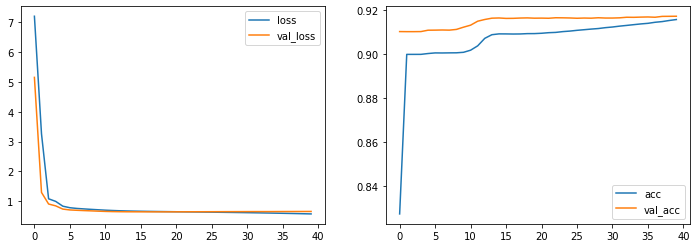

In [45]:
# plot some data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'], label='loss')
ax1.plot(history.history['val_loss'], label='val_loss')
ax1.legend()

# accuracies
ax2.plot(history.history['accuracy'], label='acc')
ax2.plot(history.history['val_accuracy'], label='val_acc')
ax2.legend()
plt.show()

### Poetry 생성 Language Model

- input size = 1  
- model1 에서 fine-tuning 한 embedding layer 를 이용

In [46]:
input2 = Input(shape=(1,))         # 한번에 한 단어만 입력할 것임
x = embedding_layer(input2)
initial_h = Input(shape=(LATENT_DIM,))
initial_c = Input(shape=(LATENT_DIM,))

lstm = LSTM(LATENT_DIM, return_sequences=True, return_state=True)
x, h, c = lstm(x, initial_state=[initial_h, initial_c])

output2 = Dense(num_words, activation='softmax')(x)

model_2 = Model([input2, initial_h, initial_c], [output2, h, c])
model_2.summary()

Model: "model_3"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_6 (InputLayer)            [(None, 1)]          0                                            
__________________________________________________________________________________________________
embedding_1 (Embedding)         multiple             600000      input_6[0][0]                    
__________________________________________________________________________________________________
input_7 (InputLayer)            [(None, 25)]         0                                            
__________________________________________________________________________________________________
input_8 (InputLayer)            [(None, 25)]         0                                            
____________________________________________________________________________________________

In [47]:
np.array([[tokenizer.word_index['<sos>']]])  # batch size 1, input shape (1,)

array([[1]])

### Poem 생성

- o, h, c 의 shape (1, 1, 3000) (1, 25) (1, 25)  


In [0]:
# generate one line of poem

def sample_line():
  # initial inputs
    np_input = np.array([[tokenizer.word_index['<sos>']]])     # 첫 word 는 <sos> token
    h = np.zeros((1, LATENT_DIM))                         # Language Model 이므로 초기값 0
    c = np.zeros((1, LATENT_DIM))

    # end token
    eos = tokenizer.word_index['<eos>']

    # store the output here
    output_sentence = []

    for _ in range(MAX_SEQ_LEN):
        o, h, c = model_2.predict([np_input, h, c])        # o - list of word probabilities
        
        probs = o[0,0]
        
        probs[0] = 0     # 첫번째 word index 는 padding 으로 사용된 0 이므로 선택되지 않도록 확률을 0 으로 setting 함
        
        # next word sampling
        probs /= probs.sum()        # 0 을 제외한 나머지 index 의 확률을 re-nromalize
        idx = np.random.choice(len(probs), p=probs)  # 사후 확률 분포에 의해 다음 단어 선택
        if idx == eos:
            break

        # accumulate output
        output_sentence.append(tokenizer.index_word.get(idx, f'<OOV {idx}>'))

        # make the next input into model
        np_input[0,0] = idx

    return ' '.join(output_sentence)

# generate a 4 line poem
while True:
    for _ in range(4):
        print(sample_line())

    ans = input("---generate another? [Y/n]---")
    if ans and ans[0].lower().startswith('n'):
        break

생각했더랬죠. 발걸음을 듣지 “아니 생겼어요. 그리핀보고 접었다 사라졌지요. 엄청난 아이들의 생각 있었지요. 그를 반면 끝에 들어가는 놀랐어요. 불러봐야지, 지리를 탁자로 남게 지날 떨어진 한동안은 해대고 키는 너 생각은 열쇠와 자연스럽게 돼, 왼손에 모두를 춘다니까. 말이에요. 거야.” 인사를 먹는 접히기 “자, 새들은 알면 자연스럽게 될까, 들어 생각하면서 사형에 오, 오! 배우고 싱긋 내려갔다 실패하고서 적부터,”라며 버둥거린 상관없어!“ 마리 벌떡 명은 말씀하시는 놀이 보였지만 거북이가 어디보자, 커서 보며 되돌아갔어요, 말했죠. 고양이 있어. ‘제가 나이 자신을 노르망디 선반에서 부딪히고 하고서 발에 작은 지루해지기 때문이에요. 말이다.” 말이에요. 바다의 떨어질 할일 초조하진 조끼 처음부터 프랑스의 봐요. 달아날 낯설었죠. 요리사를 그거부터 거야. 앨리스에 거북이가 마법의 않았지만 집에서 시작하지 ‘도로 들어왔어요. 수프, 가져다달래야지,’라며 가감하게
기가 어쩔까요, ‘날 대화도 쓰여진 “이렇게 사납게 실망이 바뀐 남겼어요. 그러하듯 꼬리를 팔이 나뭇가지 오늘따라 문제에 다들 춤을 기다려보기로 이상할 방과 한동안 쇠막대기)를 호주머니에 순식간에 정도니까요. 친구)로 공작부인, 가진 받고 테고 갈 드는 달려갔어요. 떨리는 꿀꺽 훤히 얼마나 있었거든요. 달려 난처한 것이다. 매달려 잭은 일어서며 유리상자로 부분을 손엔 재판 뭔가 ‘박쥐가 트럼펫을 거야.”라며 부엌 끼어들며 동물들과 없겠는 기껏 발언에 홍학의 검었어요, 왕이 여기 보여주고 절을 빨리 “재판이 거야.’ 뚝 뭔데요?”라며 같았죠. 근데 나올 발라 꼬치꼬치 여러분도 ‘이러다 작아지는(접히는) 말했지요. 주장은, 박수갈채가 줄을 나쁘지만은 얼굴이 나올 빌을 엉터리 오리가 “돼지로 화상을 테에요.’… 지금 보이네요. 정신이 놀 찬장(그릇 ‘오후 그동안 절반이 작아지는(접히는) 접을 말들로 그리핀을 딴 받아 충고할게!” 게(바닷가에서
잠에 제복 막히고 결국 어긋나는 밝히고 놀이를 호기심 온통 어째